# 05 — Robustez, sensibilidade e monitorização dinâmica

**Secções da dissertação:** 3.5.6 (dinâmica entre dimensões ao longo das
coortes) e 3.5.7 (sensibilidade a limiar, normalização e agregação).

Não se estimam pesos em nenhuma variante. A hierarquização compara-se por
Spearman dos *rankings dentro de cada coorte*.


In [1]:
# Arranque reproduzível: funciona a partir da raiz ou de notebooks/.
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def raiz_projeto() -> Path:
    cwd = Path.cwd().resolve()
    for cand in (cwd, cwd.parent, Path(".").resolve()):
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Não encontrei a raiz do projecto (pasta src/).")

RAIZ = raiz_projeto()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.caminhos import garantir_directorias
from src.config import aviso_parametros_pendentes, parametros_efectivos
from src.graficos_apa import CatalogoAPA, aplicar_estilo_apa, formatar_p

DIRS = garantir_directorias(RAIZ)
PARAM = parametros_efectivos(DIRS["processado"])
aplicar_estilo_apa()

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 88)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

print(aviso_parametros_pendentes(PARAM))
print("Raiz:", RAIZ)


AVISO METODOLÓGICO — parâmetros ainda não validados com o orientador.
  Limiar mínimo de movimentos: 7 (EDA (parametros_sugeridos.json))
  Ano-base da normalização: 2016 (EDA (parametros_sugeridos.json))
  Coortes: [('TRF2', 2016), ('TRF2', 2017), ('TRF2', 2018), ('TRF2', 2019), ('TRF2', 2020), ('TRF2', 2021), ('TRF2', 2022), ('TRF2', 2023), ('TRF2', 2024)] (EDA (parametros_sugeridos.json))
  O índice produzido nesta corrida é operacional, não a versão final da dissertação.
Raiz: /workspace


In [2]:
from IPython.display import display
from src.robustez import tabela_robustez
from src.monitorizacao_dinamica import avaliar_alerta, correlacao_dimensoes_por_coorte
from src.config import LIMIAR_CORRELACAO_DIMENSOES, LIMIARES_ROBUSTEZ

parquet = DIRS["processado"] / "indice.parquet"
eda = DIRS["processado"] / "processos_eda.parquet"
if not parquet.exists() or not eda.exists():
    raise FileNotFoundError(
        "Artefactos em falta. Corra 02_eda.ipynb e 03_construcao_indice.ipynb primeiro."
    )
indice = pd.read_parquet(parquet)
bruto = pd.read_parquet(eda)
PARAM = parametros_efectivos(DIRS["processado"])
ano_base = int(PARAM["ANO_BASE"] or indice["coorte"].min())
limiar = int(PARAM["LIMIAR_MINIMO_MOVIMENTOS"])
catalogo = CatalogoAPA(
    DIRS["figuras"], DIRS["tabelas"],
    DIRS["saidas"] / "relatorio_resultados.md",
    reiniciar_relatorio=False,
)
print("Ano-base:", ano_base, "Limiar principal:", limiar)


Ano-base: 2016 Limiar principal: 7


## Sensibilidade (secção 3.5.7)

Variamos um factor de cada vez: limiar ∈ {3, 5, 8, 12}; normalização
intra-processo ligada/desligada; agregação geométrica / aritmética / MPI.
A métrica é a correlação de Spearman entre o ranking da especificação
principal e o de cada alternativa, *dentro de cada coorte*.


AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.
AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.


AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.


AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.
AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 5; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 1. A decisão de recalcular os limites é do investigador.


AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 22; c̄ acima do máx: 2; H̄ abaixo do min: 55; H̄ acima do máx: 19. A decisão de recalcular os limites é do investigador.


AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.
AVISO (secção 3.5.3) — valores fora do intervalo da coorte-base 2016. NÃO recálculo automático dos min/máx. c̄ abaixo do min: 7; c̄ acima do máx: 4; H̄ abaixo do min: 18; H̄ acima do máx: 0. A decisão de recalcular os limites é do investigador.


especificação,n_comum,rho_spearman_ranking,p (APA)
"Principal (limiar EDA, intra-processo, geométrica)",5247.000,1.000,p < .001
Limiar mínimo = 3,5247.000,1.000,p < .001
Limiar mínimo = 5,5247.000,1.000,p < .001
Limiar mínimo = 8,4831.000,0.996,p < .001
Limiar mínimo = 12,2724.000,0.894,p < .001
Sem normalização intra-processo (min-max bruto),5247.000,0.484,p < .001
Média aritmética,5247.000,0.993,p < .001
MPI,5247.000,0.980,p < .001


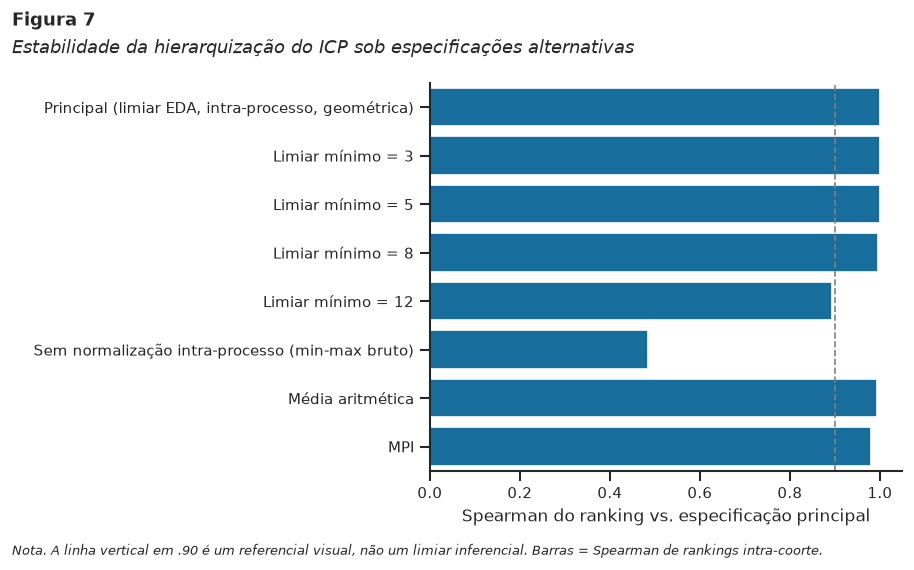

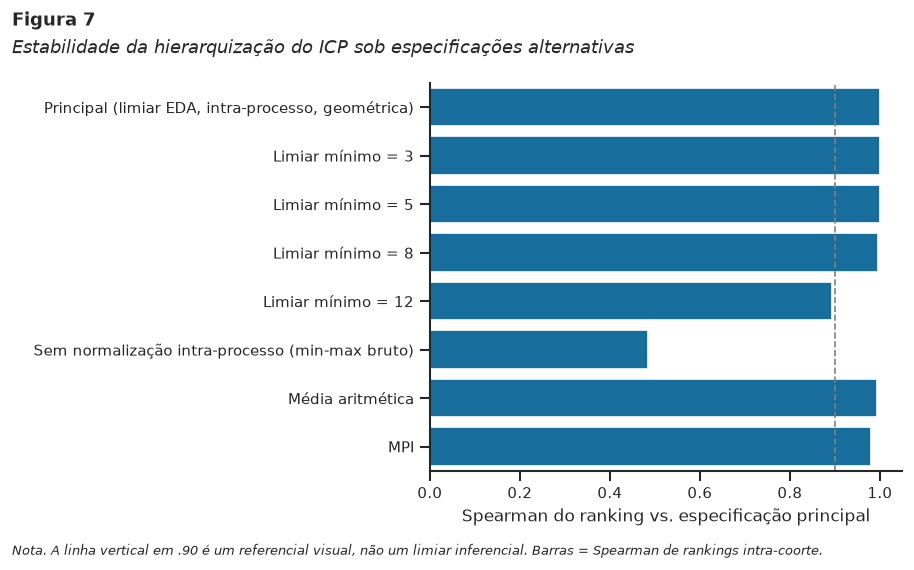

In [3]:
rob = tabela_robustez(
    bruto,
    ano_base=ano_base,
    limiar_principal=limiar,
    limiares=LIMIARES_ROBUSTEZ,
)
rob["p (APA)"] = [__import__("src.graficos_apa", fromlist=["formatar_p"]).formatar_p(p) for p in rob["p"]]
catalogo.nova_tabela(
    rob.drop(columns=["p"]),
    titulo="Correlação de Spearman entre o ranking da especificação principal e cada alternativa",
    nota=(
        "Principal = limiar da EDA, normalização intra-processo (Teorema 2 + Pielou) e média geométrica. "
        "Cada linha varia um único factor. Rankings calculados dentro de cada coorte (1 = maior ICP). "
        f"Limiares testados: {list(LIMIARES_ROBUSTEZ)}."
    ),
    nome_ficheiro="tabela_robustez_rankings",
    interpretacao="Spearman de ranking próximo de 1 indica que a hierarquização dos processos é estável à escolha operacional; quedas acentuadas identificam o factor a que o índice é mais sensível (limiar, normalização ou agregação).",
    casas=3,
)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
plot = rob.copy()
sns.barplot(
    data=plot, y="especificação", x="rho_spearman_ranking",
    ax=ax, color=sns.color_palette("colorblind")[0],
)
ax.set_xlabel("Spearman do ranking vs. especificação principal")
ax.set_ylabel("")
ax.set_xlim(0, 1.05)
ax.axvline(0.90, color="gray", linestyle="--", linewidth=1)
catalogo.nova_figura(
    fig,
    titulo="Estabilidade da hierarquização do ICP sob especificações alternativas",
    nota="A linha vertical em .90 é um referencial visual, não um limiar inferencial. Barras = Spearman de rankings intra-coorte.",
    nome_ficheiro="figura_barras_robustez",
    interpretacao="Se todas as barras ficarem altas, o capítulo de resultados pode tratar o ICP como robusto às decisões ainda em aberto; se a agregação MPI ou o limiar 3 se desviarem, isso deve ser discutido explicitamente com o orientador.",
)


## Monitorização da dinâmica (secção 3.5.6)

Spearman(c̄, H̄) em cada coorte, comparado com o valor da coorte-base. A
zona sombreada acima de 0,90 (configurável) marca o limiar em que se
recomendaria rever a arquitectura — não recalibrar pesos, porque não os há.


coorte,n,rho_spearman,rho_coorte_base,alerta_revisao,limiar_alerta,p (APA)
2016.000,645.000,0.616,0.616,False,0.900,p < .001
2017.000,623.000,0.543,0.616,False,0.900,p < .001
2018.000,610.000,0.561,0.616,False,0.900,p < .001
2019.000,562.000,0.437,0.616,False,0.900,p < .001
2020.000,655.000,0.533,0.616,False,0.900,p < .001
2021.000,607.000,0.533,0.616,False,0.900,p < .001
2022.000,672.000,0.440,0.616,False,0.900,p < .001
2023.000,547.000,0.545,0.616,False,0.900,p < .001
2024.000,326.000,0.604,0.616,False,0.900,p < .001


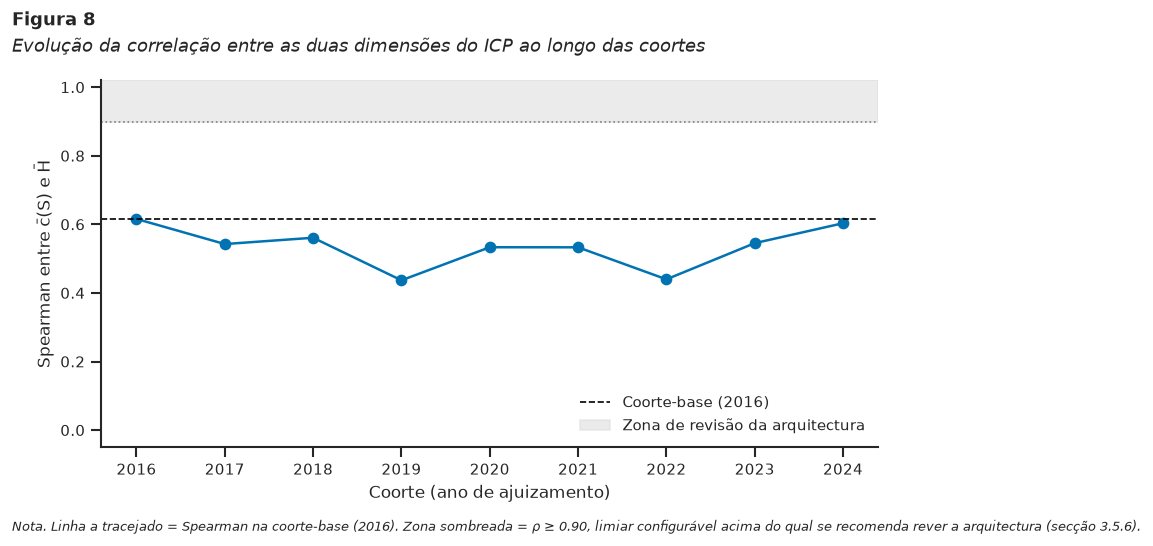

Relatório técnico: /workspace/outputs/relatorio_resultados.md
Figuras: [PosixPath('/workspace/outputs/figuras/figura_histograma_icp.png'), PosixPath('/workspace/outputs/figuras/figura_boxplot_icp_por_coorte.png'), PosixPath('/workspace/outputs/figuras/figura_histograma_comprimento_sequencia.png'), PosixPath('/workspace/outputs/figuras/figura_histograma_alfabeto_local.png'), PosixPath('/workspace/outputs/figuras/figura_dispersao_icp_duracao.png'), PosixPath('/workspace/outputs/figuras/figura_dispersao_c_h.png'), PosixPath('/workspace/outputs/figuras/figura_dinamica_correlacao_dimensoes.png'), PosixPath('/workspace/outputs/figuras/figura_barras_robustez.png')]


In [4]:
corr = correlacao_dimensoes_por_coorte(indice)
corr = avaliar_alerta(corr, ano_base=ano_base, limiar=LIMIAR_CORRELACAO_DIMENSOES)
corr["p (APA)"] = [__import__("src.graficos_apa", fromlist=["formatar_p"]).formatar_p(p) for p in corr["p"]]
catalogo.nova_tabela(
    corr.drop(columns=["p"]),
    titulo="Correlação de Spearman entre c̄(S) e H̄ em cada coorte de ajuizamento",
    nota=(
        f"Coorte-base = {ano_base}. Limiar de alerta de revisão da arquitectura = "
        f"{LIMIAR_CORRELACAO_DIMENSOES:.2f} (config.py, secção 3.5.6). "
        "alerta_revisao = True se rho ≥ limiar."
    ),
    nome_ficheiro="tabela_correlacao_dimensoes_por_coorte",
    interpretacao="Uma correlação estável e moderada ao longo das coortes sustenta a arquitectura de duas dimensões. Um salto para valores próximos de 1 na coorte mais recente é o sinal de alarme da secção 3.5.6.",
    casas=3,
)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(corr["coorte"], corr["rho_spearman"], marker="o", color=sns.color_palette("colorblind")[0])
rho_base = float(corr["rho_coorte_base"].iloc[0])
ax.axhline(rho_base, color="black", linestyle="--", linewidth=1, label=f"Coorte-base ({ano_base})")
ax.axhline(LIMIAR_CORRELACAO_DIMENSOES, color="gray", linestyle=":", linewidth=1)
ax.axhspan(LIMIAR_CORRELACAO_DIMENSOES, 1.02, color="0.85", alpha=0.5, label="Zona de revisão da arquitectura")
ax.set_xlabel("Coorte (ano de ajuizamento)")
ax.set_ylabel("Spearman entre c̄(S) e H̄")
ax.set_ylim(-0.05, 1.02)
ax.legend(frameon=False, loc="lower right")
catalogo.nova_figura(
    fig,
    titulo="Evolução da correlação entre as duas dimensões do ICP ao longo das coortes",
    nota=(
        f"Linha a tracejado = Spearman na coorte-base ({ano_base}). "
        f"Zona sombreada = ρ ≥ {LIMIAR_CORRELACAO_DIMENSOES:.2f}, limiar configurável acima do qual se recomenda rever a arquitectura (secção 3.5.6)."
    ),
    nome_ficheiro="figura_dinamica_correlacao_dimensoes",
    interpretacao="O gráfico é o instrumento de monitorização contínua do índice: como não há pesos, o que se vigia é a relação entre dimensões, não um vector de ponderadores.",
)

print("Relatório técnico:", DIRS["saidas"] / "relatorio_resultados.md")
print("Figuras:", list(DIRS["figuras"].glob("*.png")))


## Síntese

- Robustez: tabela de Spearman de rankings (limiar / normalização / agregação).
- Dinâmica: Spearman(c̄, H̄) por coorte com linha de referência na coorte-base e zona de alerta a 0,90.
- Parâmetros em `config.py` continuam pendentes de validação com o orientador; nada disto é a versão final da dissertação.
- Relatório de apoio à escrita: `outputs/relatorio_resultados.md`.
